## Importing necessary things / defining functions

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import scipy
from scipy.optimize import curve_fit


This function reads data that has been saved using the File/Print to File" option to save the MCB BUFFER (!!) in Ortec's Maestro software. <br>
The routine assumes the data file is in the same directory as this notebook. <br>
Pass it a text file produced from MAESTRO (get the file by doing Print>Print to file). The text file produced will take a form like this (example):

  ```
      <empty>
      Maestro spectrum printed on 1/13/2023 at 10:25:18 AM
      >BL-PHYS-904D9T2 Model 928 SN 14126199
      0:          0         0         0         0         0         0         0
      7:          0         0         0         0         0         0         0
      14:          0         0         0         2         6         1         9
```  

The first three lines of the file are a blank line, a descriptive header, and a metadata line. Spectrum data begins on the fourth line. <br>
Each line of data has eight values. The first value corresponds to the first bin in that respective line, and the other values are the bin counts. The first bin is called bin 0.<br>

For example, the line

```
14:          0         0         0         2         6         1         9
```
can be interpreted as 

```
"This line starts with bin 14"    [counts in bin 14]   [counts in bin 15]  ... [counts in bin 20] 
```
The first value of the next line would be 21; that line would contain the values for bins 21-27.

In [2]:
def read_maestro_text(file, calibration=(1,1)):
  ''' Read a spectrum from the Maestro software saved as text

  Parameters
  ----------
  file : string
    Text file to open
  calibration : {float,float}
    A tuple with the bin number and energy (keV) of the calibration peak

  Returns
  -------
    pandas DataFrame with columns:
      c    : channel number
      E    : calibrated energy of this channel in keV
      dE   : channel width in keV
      n    : counts recorded in this channel
      sign : statistical error on n computed as sqrt(n+1)

  '''

  with open(file) as f: # call the open file f
    bins = []
    counts = []
    line_num = 0

    for line in f.readlines(): # iterate through each line
      if line_num == 0 or line_num == 1 or line_num == 2: # skip the first and third lines
        pass
      # elif line_num == 2:
      #   print('Reading file for %s'%line)
      else:
        line_temp = line.replace(':', ' ').split() # replace each colon with a space, then .split() breaks the string whereever there is a space. 
        for j in range(1, len(line_temp)):
          # for the length of the list n, hold it temporarily so you can convert it from a string to an integer
          # then append it to the bins and counts list
          bin_temp = int(line_temp[0]) + j -1
          counts_temp = int(line_temp[0+j])
          bins.append(bin_temp)
          counts.append(counts_temp)
      line_num = line_num + 1

    # Compute errors on channel counts as sqrt(n+1) which works for both large
    # and small n's. If we've been provided an energy calibration, apply that
    # as well.
    #
    sign = np.sqrt(np.array(counts)+1)

    E = calibration[0]+calibration[1]*np.array(bins)
    dE =1 

    # returns it as a dataframe for ease of working
    df = pd.DataFrame(data={'bins':bins,
                            'E':E,
                            'dE':dE,
                            'counts':counts,
                            'sig':sign})
    return df

In [3]:
def test_read_maestro_text(file):
  ''' Unit test for function read_maestro_text() '''
  df = read_maestro_text(file,calibration=(3000,622))
  df.hist()

  plt.show()

  plt.plot(df['bins'],df['counts'])
  plt.show()

  plt.errorbar(df['E'],df['counts'],yerr=df['sig'],fmt='.')
  plt.show()
# test_read_maestro_text('cs137-13jan2023-run1.Txt')

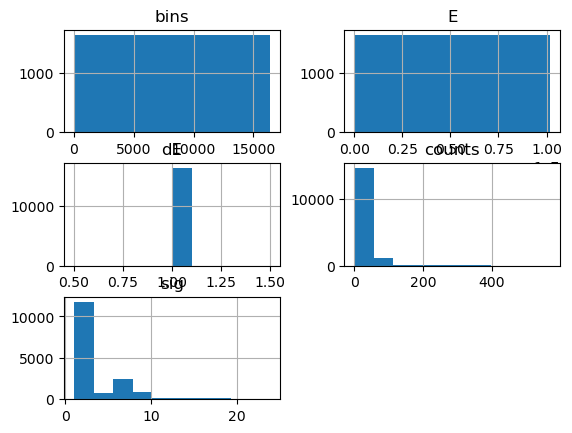

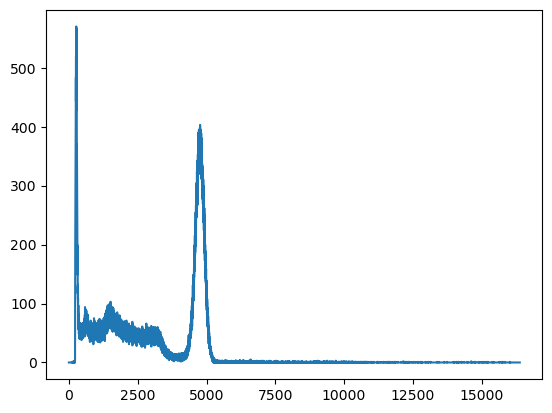

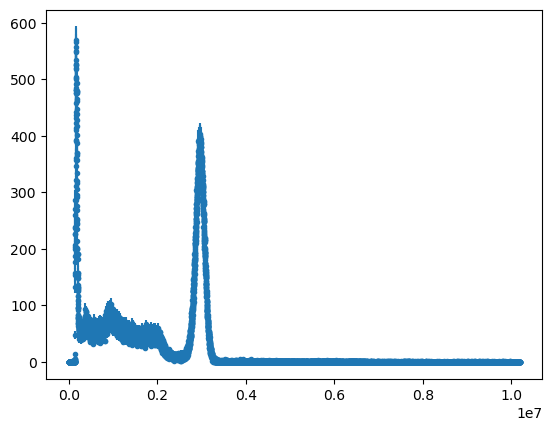

In [4]:
test_read_maestro_text('smyrichinsky_cs_137_08_25_2026.txt')

In [5]:
# routines for fitting to a single Gaussian peak; starting guesses are
# provided within the fit_peak routine (based on global properties of the
# data, they may not work in all circumstances, but the do a reasonable job
# for most cases; do you understand how they are determined?)

# Linear background: y = mx + b
# formerly peak_fcn
def gaussian_linear_bg(x, bg_intercept, bg_slope, normalization, mu, sigma):
  '''A function to represent a gaussian peak on a linear background

  Parameters
  ----------
  x - float
    the channel or energy we want to evaluate the functino for
  bg_intercept - float
    intercept of background
  bg_slope - float
    slope of background

  normalization - float
    normalization of gaussian peak
  mu - float
    peak location
  sigma - float
    peak width
  '''
  return bg_intercept + bg_slope*x + normalization * np.exp(-0.5 * ((x - mu)/sigma)**2)

In [6]:
def peak_fcn(x, ab, mb, ap, xp, sigp):
  '''A function to represent a gaussian peak on a linear background

  Parameters
  ----------
  x - float
    the channel or energy we want to evaluate the functino for
  ab - float
    intercept of background
  mb - float
    slope of background
  ap - float
    normalization of gaussian peak
  xp - float
    peak location
  sigp - float
    peak width
  '''
  return ab+mb*x + ap*np.exp(-0.5*((x-xp)/sigp)**2)

def fit_peak(df, roi=(0,999999), mode='raw', draw=False):
  ''' Fit a peak to a particular region of interest
  Parameters
  ----------
  df : DataFrame
    The DataFrame for the spectrum we want to fit
  roi : tuple, optional
    The left and right edges of the region of interest we want to fit
  display : bool
    Display the results?

  Returns
  -------
    tuple of floats (peak, sigma peak, width, sigma width)
  '''
  ds = df.loc[(df["bins"]>=roi[0]) & (df["bins"]<=roi[1])]
  #
  # Provide some seeds for the fit. Asusme that the peak is roughly in the
  # center of the region of interest, has a width which isn't too different
  # from the width of the region of interest and is about as high as the
  # highest bin count insider the region of interest.
  # Seed the background at 1/10th the peak and have it fall off like
  # 1/(width of the region of interest)
  #

  # provide the fit with guesses it can build upon. try to be somewhat accurate

  xp    = 0.5*(roi[0]+roi[1])
  ap    = df["counts"].max()
  sigp  = 0.5*(roi[1]-roi[0])
  # DVB the initial gueses below are for debugging, I need to
  # come up with a universal guess (how to specify E[roi[0]]??)
  if mode == 'cal': xp = 0.5*(ds["E"].min() + ds["E"].max())
  if mode == 'cal': ap = df["n"].max()
  if mode == 'cal': sigp = 0.5*(ds["E"].max()-ds["E"].min())
  ab    = 0.1*ap
  mb    = 0.0
  guess = [ab, mb, ap, xp, sigp]

  if mode == 'raw': x= ds["bins"]
  if mode == 'cal': x= ds["E"]
  y= ds["counts"]
  s= ds["sig"]

  (popt,pcov) = curve_fit(peak_fcn, x, y, sigma=s, p0=guess, absolute_sigma=True)
  perr        = np.sqrt(np.diag(pcov))
  best_fit_x  = x
  best_fit_y  = peak_fcn(best_fit_x,*popt)
  chisq       = np.sum(((y-best_fit_y)/s)**2)
  ndof        = len(best_fit_x)-5

  print('Best fit: chisq=%f / %d DOF'%(chisq, ndof))
  print(' intercept = %f +/- %f'%(popt[0],perr[0]))
  print(' slope = %f +/- %f'%(popt[1],perr[1]))
  print(' peak height = %f +/- %f'%(popt[2],perr[2]))
  print(' peak center = %f +/- %f'%(popt[3],perr[3]))
  print(' peak width  = %f +/- %f'%(popt[4],perr[4]))

  if draw:
    if mode == 'cal': draw_spectrum_calibrated(ds)
    if mode == 'raw': draw_spectrum_raw(ds)
    plt.plot(best_fit_x, best_fit_y, 'r-', zorder=100)

  return (popt[3], perr[3], popt[4], perr[4])


In [7]:
def draw_spectrum_raw(df,xlabel='channel'):
  plt.errorbar(df["bins"],df["counts"], yerr=df["sig"], fmt='.')
  plt.grid()
  plt.xlabel(xlabel)
  plt.ylabel('Counts')
  plt.semilogy()
  # Note, as read in from Maestro, the data is expressed vs. channel number
  # this package facilitates changing that over to energy

def draw_spectrum_calibrated(df,xlabel='Energy (keV)'):
  plt.errorbar(df["E"],df["n"], yerr=df["sig"], fmt='.')
  plt.grid()
  plt.semilogy()
  plt.xlabel(xlabel)
  plt.ylabel('Counts')
  # Note, as read in from Maestro, the data is expressed vs. channel number
  # this package facilitates changing that over to energy

def draw_roi(df,roi=(0,999999),xlabel='channel'):
  ds=df.loc[(df["bins"]>=roi[0]) & (df["bins"]<=roi[1])]
  plt.errorbar(ds["bins"],ds["counts"], yerr=ds["sig"], fmt='.')
  plt.grid()
  plt.xlabel(xlabel)
  plt.ylabel('Counts')
  plt.semilogy()

In [8]:
# this routine fits to a pair of (possibly overlapping) Gaussians.
# this may work better than the above peak_fit routine for data sets
# where the peaks are not well-separated
def peak_fcn2(x, ab, mb, ap1, xp1, sigp1, ap2, xp2, sigp2):
  '''A function to represent a gaussian peak on a linear background

  Parameters
  ----------
  x - float
    the channel or energy we want to evaluate the functino for
  ab - float
    intercept of background
  mb - float
    slope of background
  ap - float
    normalization of gaussian peak
  xp - float
    peak location
  sigp - float
    peak width
  '''
  return ab+mb*x + ap1*np.exp(-0.5*((x-xp1)/sigp1)**2)+ ap2*np.exp(-0.5*((x-xp2)/sigp2)**2)
#...............................................................................

# def fit_peak2(df, Gx1, GA1, Gx2, GA2, roi=(0,999999), mode='raw', draw=False):
def fit_peak2(df,roi=(0,999999), mode='raw', draw=False):
  ''' Fit two peaks to a particular region of interest
  Parameters
  ----------
  df : DataFrame
    The DataFrame for the spectrum we want to fit
  roi : tuple, optional
    The left and right edges of the region of interest we want to fit
  display : bool
    Display the results?

  Returns
  -------
    tuple of floats (peak, sigma peak, width, sigma width)
  '''
  ds = df.loc[(df["bins"]>=roi[0]) & (df["bins"]<=roi[1])]
  #
  # Provide some seeds for the fit. Asusme that the peak is roughly in the
  # center of the region of interest, has a width which isn't too different
  # from the width of the region of interest and is about as high as the
  # highest bin count insider the region of interest.
  # Seed the background at 1/10th the peak and have it fall off like
  # 1/(width of the region of interest)
  #

  #  xp    = 0.5*(roi[0]+roi[1])
  #   ap    = df["counts"].max()
  #   sigp  = 0.5*(roi[1]-roi[0])
  #   # DVB the initial gueses below are for debugging, I need to
  #   # come up with a universal guess (how to specify E[roi[0]]??)
  #   if mode == 'cal': xp = 0.5*(ds["E"].min() + ds["E"].max())
  #   if mode == 'cal': ap = df["n"].max()
  #   if mode == 'cal': sigp = 0.5*(ds["E"].max()-ds["E"].min())
  #   ab    = 0.1*ap
  #   mb    = 0.0
  #   guess = [ab, mb, ap, xp, sigp]

  xp1    = 0.5*(roi[0]+roi[1])
  ap1    = df["counts"].max()
  sigp1  = 0.5*(roi[1]-roi[0])
  xp2    = 0.5*(roi[0]+roi[1])
  ap2    = df["counts"].max()
  sigp2  = 0.5*(roi[1]-roi[0])


  # DVB the initial gueses below are for debugging, I need to
  # come up with a universal guess (how to specify E[roi[0]]??)
  if mode == 'cal': xp1 = 0.5*(ds["E"].min() + ds["E"].max())
  if mode == 'cal': ap1 = df["counts"].max()
  if mode == 'cal': sigp1 = 0.5*(ds["E"].max()-ds["E"].min())
  if mode == 'cal': xp2 = 0.2*(ds["E"].min() + ds["E"].max())
  if mode == 'cal': ap2 = df["counts"].max()
  if mode == 'cal': sigp2 = 0.5*(ds["E"].max()-ds["E"].min())
  ab    = 0.1*ap1
  mb    = 0.0
  guess = [ab, mb, ap1, xp1, sigp1, ap2, xp2, sigp2]

  if mode == 'raw': x= ds["bins"]
  if mode == 'cal': x= ds["E"]
  y= ds["counts"]
  s= ds["sig"]

  (popt,pcov) = curve_fit(peak_fcn2, x, y, sigma=s, p0=guess, absolute_sigma=True)
  perr        = np.sqrt(np.diag(pcov))
  best_fit_x  = x
  best_fit_y  = peak_fcn2(best_fit_x,*popt)
  chisq       = np.sum(((y-best_fit_y)/s)**2)
  ndof        = len(best_fit_x)-5

  print('Best fit: chisq=%f / %d DOF'%(chisq, ndof))
  print(' intercept = %f +/- %f'%(popt[0],perr[0]))
  print(' slope = %f +/- %f'%(popt[1],perr[1]))
  print(' peak1 height = %f +/- %f'%(popt[2],perr[2]))
  print(' peak1 center = %f +/- %f'%(popt[3],perr[3]))
  print(' peak1 width  = %f +/- %f'%(popt[4],perr[4]))
  print(' peak2 height = %f +/- %f'%(popt[5],perr[5]))
  print(' peak2 center = %f +/- %f'%(popt[6],perr[6]))
  print(' peak2 width = %f +/-  %f'%(popt[7],perr[7]))

  if draw:
    if mode == 'cal': draw_spectrum_calibrated(ds)
    if mode == 'raw': draw_spectrum_raw(ds)
    plt.plot(best_fit_x, best_fit_y, 'r-', zorder=100)

  return (popt[3], perr[3], popt[4], perr[4])



## Cs-137 peak fits

Cs-137 has a large probability of emitting a 661 keV gamma in its decay scheme. <br>
That large peak is likely what we see in the spectra.

However, we need more than one peak to have a confident energy calibration. 

Besides the 661 keV peak, this [source](http://www.lnhb.fr/Laraweb/) lists other gamma peaks that could be used for calibration.

In [9]:
counts_array = np.array(df['counts'])
print(type(counts_array))
print(len(counts_array))

peak_indices = scipy.signal.find_peaks(counts_array, width = 10, height = 100)
print(peak_indices)

NameError: name 'df' is not defined

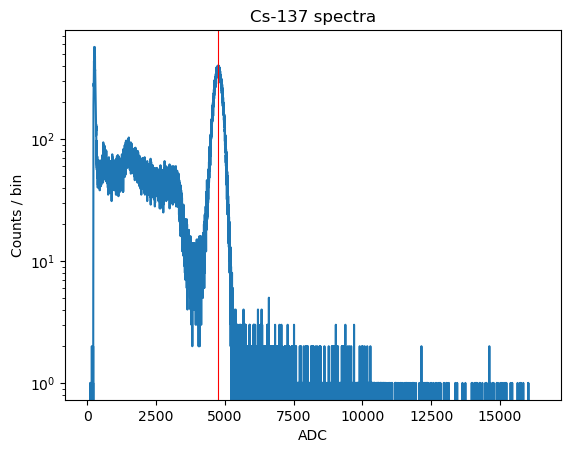

In [ ]:
df = read_maestro_text('smyrichinsky_cs_137_08_25_2026.txt')
sample = "Cs-137"

fig, ax = plt.subplots()
ax.plot(df['bins'], df['counts'])
# ax.set_xlim(1000, 3000)
ax.set_xlabel("ADC")
ax.set_ylabel("Counts / bin")
ax.set_yscale("log")
ax.set_title(f"{sample} spectra")

ax.axvline(x = 4767, lw = 0.8, color = "r")
# ax.axvline(x = 269, lw = 0.8, color = "r")


Best fit: chisq=2185.944216 / 1996 DOF
 intercept = 30.893561 +/- 0.452814
 slope = -0.005665 +/- 0.000092
 peak height = 361.844489 +/- 1.204001
 peak center = 4756.342793 +/- 0.445410
 peak width  = 160.334187 +/- 0.357011


Text(0.5, 1.0, 'Cs-137 peak fit at channel 4750')

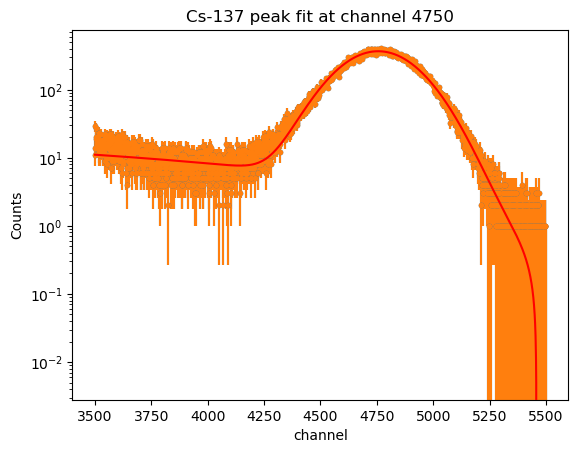

In [10]:
Cs_137_df = read_maestro_text('smyrichinsky_cs_137_08_25_2026.txt')
draw_roi(Cs_137_df,roi=(3500,5500),xlabel="channel")
fit_peak(Cs_137_df,roi=(3500,5500),mode='raw', draw=True)
plt.title("Cs-137 peak fit at channel 4750")

## Co-60 peak fits

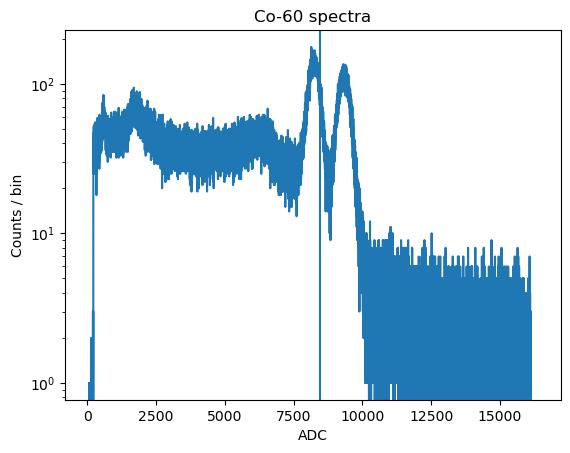

In [ ]:
df = read_maestro_text('smyrichinsky_co_60_08_25_2026.txt')
sample = "Co-60"
# fit_peak(df,roi=(180,250),mode='raw', draw=True)

#   plt.plot(df['bins'],df['counts'])
#   plt.show()

fig, ax = plt.subplots()
ax.plot(df['bins'], df['counts'])
# ax.set_yscale("log")
ax.set_xlabel("ADC")
ax.set_ylabel("Counts / bin")
ax.set_yscale("log")
ax.set_title(f"{sample} spectra")

ax.axvline(x = 8457)



Best fit: chisq=4446.931795 / 3996 DOF
 intercept = 99.651075 +/- 0.859547
 slope = -0.009648 +/- 0.000116
 peak1 height = 119.909933 +/- 0.705434
 peak1 center = 8246.235502 +/- 1.103874
 peak1 width  = 202.499597 +/- 1.054126
 peak2 height = 103.091604 +/- 0.596721
 peak2 center = 9343.887198 +/- 1.187251
 peak2 width = 223.731957 +/-  1.450473


Text(0.5, 1.0, 'Co-60 peak fits in channels 8000-9500')

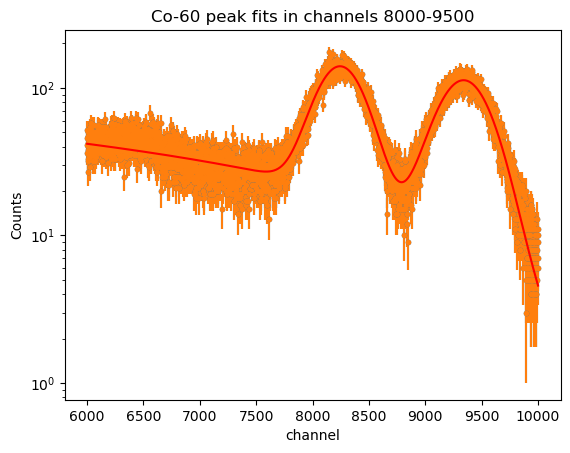

In [11]:
Co_60_df = read_maestro_text('smyrichinsky_co_60_08_25_2026.txt')
draw_roi(Co_60_df,roi=(6000,10000),xlabel="channel")
fit_peak2(Co_60_df,roi=(6000,10000),mode='raw', draw=True)
plt.title("Co-60 peak fits in channels 8000-9500")

## Na-22 peak fits

Text(0.5, 1.0, 'Na-22 spectra')

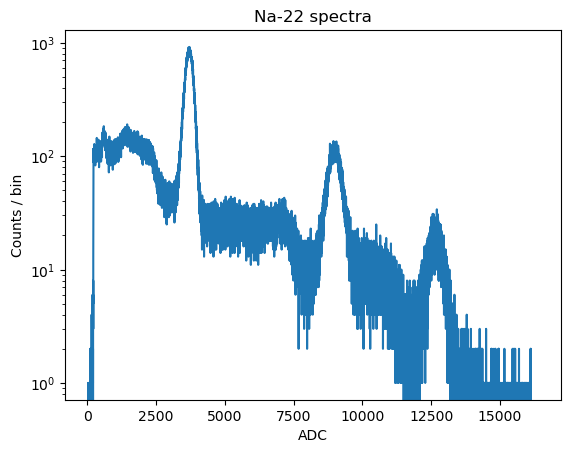

In [ ]:
df = read_maestro_text('smyrichinsky_n_22_08_25_2026.txt')
sample = "Na-22"
# fit_peak(df,roi=(180,250),mode='raw', draw=True)

#   plt.plot(df['bins'],df['counts'])
#   plt.show()

fig, ax = plt.subplots()
ax.plot(df['bins'], df['counts'])
# ax.set_yscale("log")
ax.set_xlabel("ADC")
ax.set_ylabel("Counts / bin")
ax.set_yscale("log")
ax.set_title(f"{sample} spectra")



Best fit: chisq=3770.007339 / 2496 DOF
 intercept = 80.649444 +/- 0.706741
 slope = -0.012063 +/- 0.000173
 peak height = 814.477766 +/- 2.008472
 peak center = 3704.267952 +/- 0.294112
 peak width  = 138.218217 +/- 0.246255


Text(0.5, 1.0, 'Na-22 peak fit in channels 3500-4000')

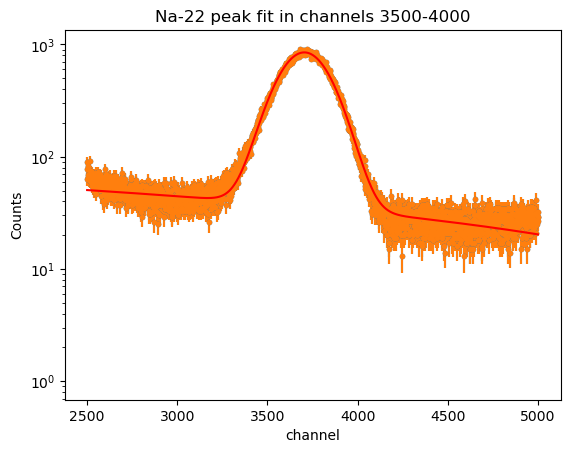

In [12]:
Na_22_df = read_maestro_text('smyrichinsky_na_22_08_25_2026.txt')
draw_roi(Na_22_df,roi=(2500,5000),xlabel="channel")
fit_peak(Na_22_df,roi=(2500,5000),mode='raw', draw=True)
plt.title("Na-22 peak fit in channels 3500-4000")

## Calibration fit using peak fit values

<class 'numpy.ndarray'>
Slope (m): 0.1430
Intercept (b): -10.0922


Text(0.5, 1.0, 'Calibration linear fit')

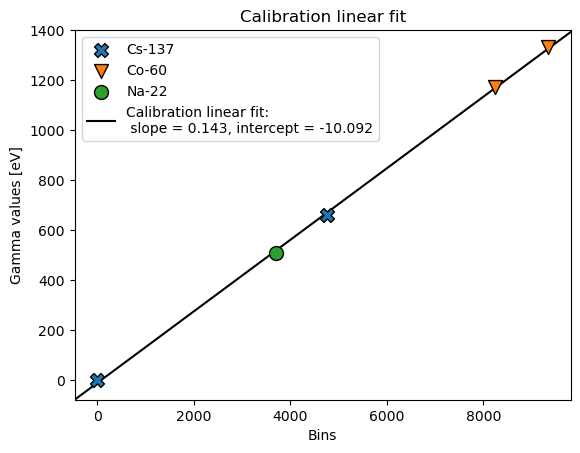

In [ ]:
Cs_137_bins = np.array([0, 4767])
Cs_137_bins_error = np.array([0.445]) # should really be called "fit error"?
Cs_137_eV = np.array([0, 661])

Co_60_bins = np.array([8246, 9343])
Co_60_bins_error = np.array([1.103, 1.187])
Co_60_eV = np.array([1173, 1332])

Na_22_bins = np.array([3704])
Na_22_bins_error = np.array([0.294])
Na_22_eV = np.array([511])

all_bins = []
all_eV = []
print(type(Na_22_bins))

all_bins = np.concatenate([Cs_137_bins, Co_60_bins, Na_22_bins])
all_eV = np.concatenate([Cs_137_eV, Co_60_eV, Na_22_eV])

m, b = np.polyfit(all_bins, all_eV, deg=1)
print(f"Slope (m): {m:.4f}")
print(f"Intercept (b): {b:.4f}")

fig, ax = plt.subplots()
ax.scatter(Cs_137_bins, Cs_137_eV, marker = "X", zorder = 20, s = 100, label = "Cs-137", edgecolors= "black")
ax.errorbar(Cs_137_bins, Cs_137_eV, yerr = Cs_137_bins_error,  fmt='o', c='black', ms=2, lw=0.8)

ax.scatter(Co_60_bins, Co_60_eV, marker = "v", zorder = 20, s = 100, label = "Co-60", edgecolors= "black")
ax.errorbar(Co_60_bins, Co_60_eV, yerr = Co_60_bins_error, fmt = "o", c = "black", ms = 2, lw = 0.8)

ax.scatter(Na_22_bins, Na_22_eV, marker = "o", zorder = 20, s = 100, label = "Na-22", edgecolors= "black")
ax.errorbar(Na_22_bins, Na_22_eV, yerr = Na_22_bins_error, fmt = "o", c = "black", ms = 2, lw = 0.8)

ax.axline((0, b), slope = m, label = f"Calibration linear fit: \n slope = {m:.3f}, intercept = {b:.3f}", color = "black")

ax.legend()

ax.set_xlabel("Bins")
ax.set_ylabel("Gamma values [eV]")
ax.set_title("Calibration linear fit")

## Unknown spectra

Text(0.5, 1.0, 'Unknown spectra')

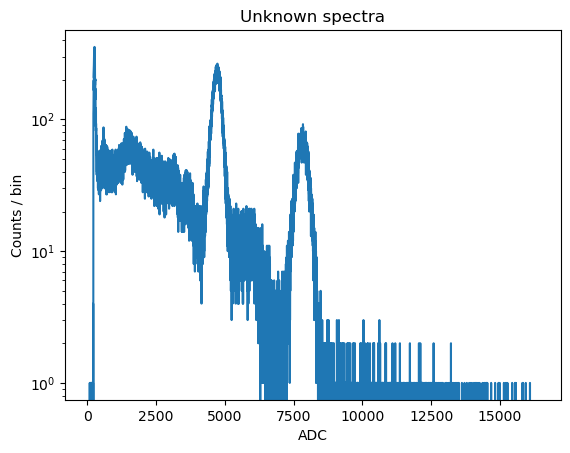

In [ ]:
df = read_maestro_text('smyrichinsky_unknown_08_25_2026.txt')
sample = "Unknown"
# fit_peak(df,roi=(180,250),mode='raw', draw=True)

#   plt.plot(df['bins'],df['counts'])
#   plt.show()

fig, ax = plt.subplots()
ax.plot(df['bins'], df['counts'])
# ax.set_yscale("log")
ax.set_xlabel("ADC")
ax.set_ylabel("Counts / bin")
ax.set_yscale("log")
ax.set_title(f"{sample} spectra")

Best fit: chisq=2621.215488 / 1796 DOF
 intercept = 47.004472 +/- 1.006102
 slope = -0.007445 +/- 0.000237
 peak height = 210.344284 +/- 0.968239
 peak center = 4715.881607 +/- 0.650621
 peak width  = 157.895525 +/- 0.617829


Text(0.5, 1.0, 'Unknown spectra peak fit at channel 4750')

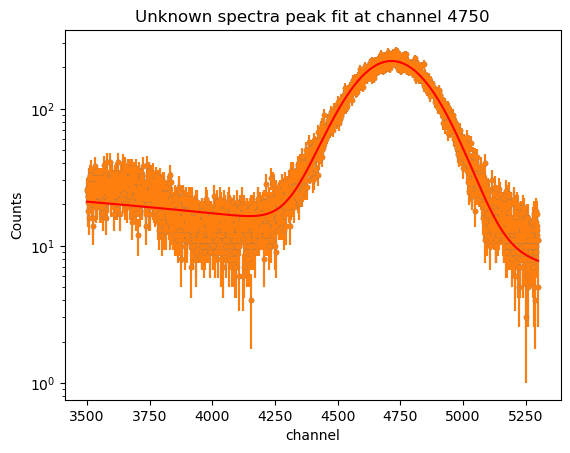

In [13]:
Na_22_df = read_maestro_text('smyrichinsky_unknown_08_25_2026.txt')
draw_roi(Na_22_df,roi=(3500,5300),xlabel="channel")
fit_peak(Na_22_df,roi=(3500,5300),mode='raw', draw=True)
plt.title("Unknown spectra peak fit at channel 4750")

Best fit: chisq=1330.289278 / 1496 DOF
 intercept = 10.594445 +/- 0.940538
 slope = -0.001269 +/- 0.000123
 peak height = 66.532151 +/- 0.454919
 peak center = 7820.452675 +/- 1.333910
 peak width  = 212.235206 +/- 1.279938


Text(0.5, 1.0, 'Unknown spectra peak fit at channel 7800')

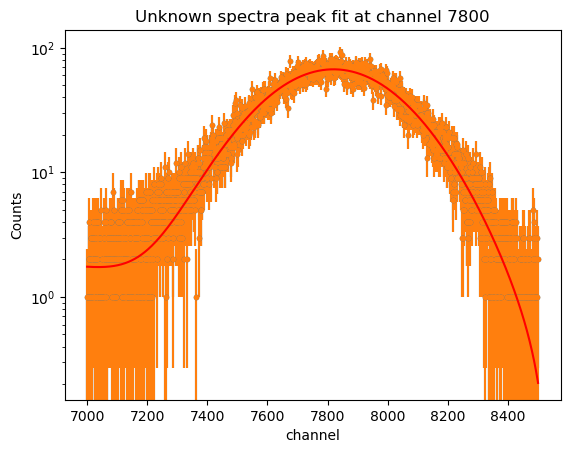

In [14]:
Na_22_df = read_maestro_text('smyrichinsky_unknown_08_25_2026.txt')
draw_roi(Na_22_df,roi=(7000,8500),xlabel="channel")
fit_peak(Na_22_df,roi=(7000,8500),mode='raw', draw=True)
plt.title("Unknown spectra peak fit at channel 7800")